# Generalized Lie Group Reachability on SE_2(3)

Two-layer cascaded reachability architecture:
1. **Layer 1**: Rotational dynamics (Euler's equations) -- polytopic LMI
2. **Layer 2**: SE_2(3) kinematics (9x9 log-linear) -- exact, with disturbance channels

Uses CasADi backend for all simulation (compiled from Modelica via `rumoca.generate_code`).
Minimum-snap trajectory planning provides exact angular velocity, angular acceleration,
and feedforward moment references via differential flatness.

In [28]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
import json as _json
import numpy as np
import casadi as ca
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import rumoca

from cp_reach.planning import plan_minimum_derivative_trajectory
from cp_reach.planning.polynomial import compute_trajectory
from cp_reach.reachability import quadrotor_flatness, load_lie_spec, partition_states

plt.rcParams['figure.dpi'] = 100

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
# =============================================================================
# CONFIGURATION
# =============================================================================

MODELICA_FILE = "models/quadrotor_closed_loop2.mo"
MODEL_NAME = "QuadrotorClosedLoop2"
LIE_SPEC_FILE = "models/quadrotor_closed_loop_lie.json"
OUTPUT_DIR = "output_quadrotor"

# Disturbance inputs (model inputs treated as bounded disturbances)
DIST_INPUTS = {"d_p": 0.01, "d_q": 0.01, "d_r": 0.01}  # gyro bias (rad/s)

# Disturbance states (model states treated as bounded disturbances, not dynamics)
DIST_STATES = {"vel_err_ix": 0.05, "vel_err_iy": 0.05, "vel_err_iz": 0.05}  # integrator error

# Number of LMI sample points along trajectory
NUM_SAMPLES = 20

os.makedirs(OUTPUT_DIR, exist_ok=True)

## Compile Modelica Model (CasADi Backend)

In [30]:
print(f"Compiling {MODELICA_FILE} with CasADi backend...")
with open(MODELICA_FILE) as f:
    source = f.read()

dae_json = rumoca.compile(source, MODEL_NAME)
casadi_code = rumoca.generate_code(dae_json, "casadi")

ns = {}
exec(casadi_code, ns)
model = ns["create_model"]()

# Extract variable names from generated model
state_names = model["state_names"]
param_names = model["param_names"]
input_names = model["input_names"]
n_x, n_z, n_u = model["n_x"], model["n_z"], model["n_u"]

# Parameter values
p0 = model["p0"]
param_dict = dict(zip(param_names, p0))
mass = float(param_dict["mass"])
g = float(param_dict["g"])

print(f"States ({n_x}): {state_names}")
print(f"Inputs ({n_u}): {input_names}")
print(f"mass={mass}, g={g}")

Compiling models/quadrotor_closed_loop2.mo with CasADi backend...
States (21): ['R11', 'R12', 'R13', 'R21', 'R22', 'R23', 'R31', 'R32', 'R33', 'omega_x', 'omega_y', 'omega_z', 'px', 'py', 'pz', 'vel_err_ix', 'vel_err_iy', 'vel_err_iz', 'vx', 'vy', 'vz']
Inputs (27): ['Mx_ff', 'My_ff', 'Mz_ff', 'R11_ref', 'R12_ref', 'R13_ref', 'R21_ref', 'R22_ref', 'R23_ref', 'R31_ref', 'R32_ref', 'R33_ref', 'ax_ref', 'ay_ref', 'az_ref', 'd_p', 'd_q', 'd_r', 'omega_x_ref', 'omega_y_ref', 'omega_z_ref', 'px_ref', 'py_ref', 'pz_ref', 'vx_ref', 'vy_ref', 'vz_ref']
mass=2.496, g=9.80665


## Load Lie Group Specification

In [31]:
lie_spec = load_lie_spec(LIE_SPEC_FILE)

group = lie_spec['lie_groups'][0]
print(f"Lie group: {group['type']}")
print(f"  Rotation states: {group['rotation_states']}")
print(f"  Velocity states: {group['velocity_states']}")
print(f"  Position states: {group['position_states']}")
print(f"  Body angular velocity: {group['body_angular_velocity']}")
print(f"  Body acceleration: {group['body_acceleration']}")

# Disturbance config (from notebook config cell)
dist_input_names = list(DIST_INPUTS.keys())
dist_input_bounds = np.array(list(DIST_INPUTS.values()))
dist_state_names = list(DIST_STATES.keys())
dist_state_bounds = np.array(list(DIST_STATES.values()))

print(f"\nDisturbances:")
print(f"  Inputs:  {dist_input_names} (bounds: {dist_input_bounds})")
print(f"  States:  {dist_state_names} (bounds: {dist_state_bounds})")

print(f"\nModel parameters:")
for k, v in param_dict.items():
    print(f"  {k} = {v}")

Lie group: SE23
  Rotation states: ['R11', 'R12', 'R13', 'R21', 'R22', 'R23', 'R31', 'R32', 'R33']
  Velocity states: ['vx', 'vy', 'vz']
  Position states: ['px', 'py', 'pz']
  Body angular velocity: ['omega_x', 'omega_y', 'omega_z']
  Body acceleration: ['a_x', 'a_y', 'a_z']

Disturbances:
  Inputs:  ['d_p', 'd_q', 'd_r'] (bounds: [0.01 0.01 0.01])
  States:  ['vel_err_ix', 'vel_err_iy', 'vel_err_iz'] (bounds: [0.05 0.05 0.05])

Model parameters:
  Ixx = 0.0233
  Iyy = 0.0344
  Izz = 0.0527
  Ki_vx = 0.1
  Ki_vy = 0.1
  Ki_vz = 0.1
  Kp_px = 1.0
  Kp_py = 1.0
  Kp_pz = 1.5
  Kp_vx = 2.0
  Kp_vy = 2.0
  Kp_vz = 2.5
  Kr_x = 6.0
  Kr_y = 6.0
  Kr_z = 4.0
  Kw_x = 5.0
  Kw_y = 5.0
  Kw_z = 4.0
  g = 9.80665
  mass = 2.496


## Plan Reference Trajectory

Minimum-snap (4th derivative) polynomial trajectory through waypoints at constant altitude.
Snap is needed for exact angular acceleration and feedforward moments via differential flatness.

In [32]:
ALTITUDE = 1.0

# Simple trajectory: gentle move with low accelerations
waypoint_xyz = np.array([
    [0.0, 0.0, ALTITUDE],
    [3.0, 0.0, ALTITUDE],
    [5.0, 2.0, ALTITUDE],
    [5.0, 2.0, ALTITUDE],
])

waypoint_vel = np.array([
    [0.0, 0.0, 0.0],
    [1.0, 0.0, 0.0],
    [0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0],
])

n_waypoints = len(waypoint_xyz)
n_segments = n_waypoints - 1
T_segments = np.array([5.0, 4.0, 3.0])

# Convert to NED (negate z)
waypoint_ned = waypoint_xyz.copy()
waypoint_ned[:, 2] *= -1
vel_ned = waypoint_vel.copy()
vel_ned[:, 2] *= -1

print("Planning minimum-snap trajectory...")
trajectories = {}
for d, axis in enumerate(["x", "y", "z"]):
    bc = np.zeros((4, n_waypoints, 1))
    bc[0, :, 0] = waypoint_ned[:, d]
    bc[1, :, 0] = vel_ned[:, d]

    traj = plan_minimum_derivative_trajectory(
        bc=bc, min_deriv=4, poly_deg=7, T_guess=T_segments, bc_deriv=4
    )

    coeffs_d = traj.metadata["coeffs"][0]
    T_opt = traj.metadata["segment_times"]
    snap_d = compute_trajectory(coeffs_d, T_opt, poly_deg=7, deriv=4)["x"]

    trajectories[axis] = {
        "t": traj.t,
        "pos": traj.x[:, 0],
        "vel": traj.metadata["derivatives"]["vel"][:, 0],
        "acc": traj.metadata["derivatives"]["acc"][:, 0],
        "jerk": traj.metadata["derivatives"]["jerk"][:, 0],
        "snap": snap_d,
    }

t_eval = trajectories["x"]["t"]
T_total = t_eval[-1]

p_ref = np.column_stack([trajectories[a]["pos"] for a in ["x", "y", "z"]])
v_ref = np.column_stack([trajectories[a]["vel"] for a in ["x", "y", "z"]])
a_ref = np.column_stack([trajectories[a]["acc"] for a in ["x", "y", "z"]])
jerk_ref = np.column_stack([trajectories[a]["jerk"] for a in ["x", "y", "z"]])
snap_ref = np.column_stack([trajectories[a]["snap"] for a in ["x", "y", "z"]])

# Remove duplicate time points at segment boundaries
unique_mask = np.concatenate([[True], np.diff(t_eval) > 0])
t_eval = t_eval[unique_mask]
p_ref = p_ref[unique_mask]
v_ref = v_ref[unique_mask]
a_ref = a_ref[unique_mask]
jerk_ref = jerk_ref[unique_mask]
snap_ref = snap_ref[unique_mask]

print(f"Trajectory: t=[0, {T_total:.1f}]s, {len(t_eval)} points, {n_segments} segments")
print(f"Waypoints (x, y, z-up):")
for i, wp in enumerate(waypoint_xyz):
    print(f"  {i}: [{wp[0]:5.1f}, {wp[1]:5.1f}, {wp[2]:5.1f}]")

Planning minimum-snap trajectory...
Trajectory: t=[0, 12.0]s, 298 points, 3 segments
Waypoints (x, y, z-up):
  0: [  0.0,   0.0,   1.0]
  1: [  3.0,   0.0,   1.0]
  2: [  5.0,   2.0,   1.0]
  3: [  5.0,   2.0,   1.0]


## Differential Flatness

Compute full reference (R, omega, alpha, thrust, feedforward moments) from the position trajectory.
Minimum-snap provides exact snap, so angular acceleration and feedforward moments are analytic.

In [33]:
N = len(t_eval)
Ixx_val = float(param_dict["Ixx"])
Iyy_val = float(param_dict["Iyy"])
Izz_val = float(param_dict["Izz"])

flat_ref = quadrotor_flatness(
    p_ref, v_ref, a_ref, jerk_ref, mass, g,
    snap_ref=snap_ref,
    inertia=np.array([Ixx_val, Iyy_val, Izz_val]),
)

R_ref = flat_ref["R_ref"]
omega_ref = flat_ref["omega_ref"]
alpha_ref = flat_ref["alpha_ref"]
T_ref_val = flat_ref["T_ref"]
a_body_ref = flat_ref["a_body_ref"]
Mx_ff_ref = flat_ref["M_ff"][:, 0]
My_ff_ref = flat_ref["M_ff"][:, 1]
Mz_ff_ref = flat_ref["M_ff"][:, 2]

print(f"Thrust range: [{T_ref_val.min():.2f}, {T_ref_val.max():.2f}] N")
print(f"Max omega_ref: {np.max(np.abs(omega_ref), axis=0)} rad/s")
print(f"Body accel at hover: a_body = {a_body_ref[0]} m/s^2")

Thrust range: [24.48, 24.60] N
Max omega_ref: [0.16700228 0.0376473  0.0079809 ] rad/s
Body accel at hover: a_body = [ 0.       0.      -9.80665] m/s^2


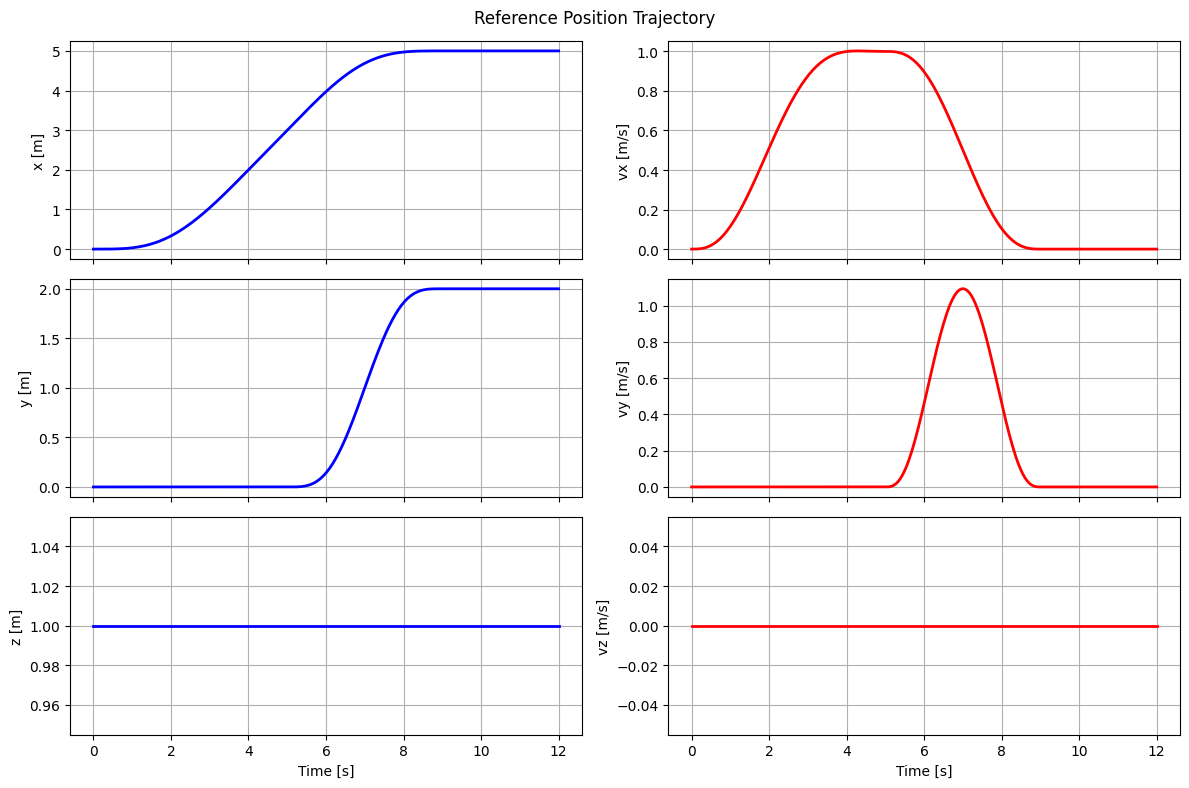

In [34]:
# Plot reference trajectory
z_sign = [1, 1, -1]  # NED to z-up display

fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True)
labels_pos = ['x [m]', 'y [m]', 'z [m]']
labels_vel = ['vx [m/s]', 'vy [m/s]', 'vz [m/s]']

for i in range(3):
    axes[i, 0].plot(t_eval, z_sign[i] * p_ref[:, i], 'b-', linewidth=2)
    axes[i, 0].set_ylabel(labels_pos[i])
    axes[i, 0].grid(True)
    axes[i, 1].plot(t_eval, z_sign[i] * v_ref[:, i], 'r-', linewidth=2)
    axes[i, 1].set_ylabel(labels_vel[i])
    axes[i, 1].grid(True)

axes[-1, 0].set_xlabel('Time [s]')
axes[-1, 1].set_xlabel('Time [s]')
fig.suptitle('Reference Position Trajectory')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/ref_trajectory.png", dpi=150)
plt.show()

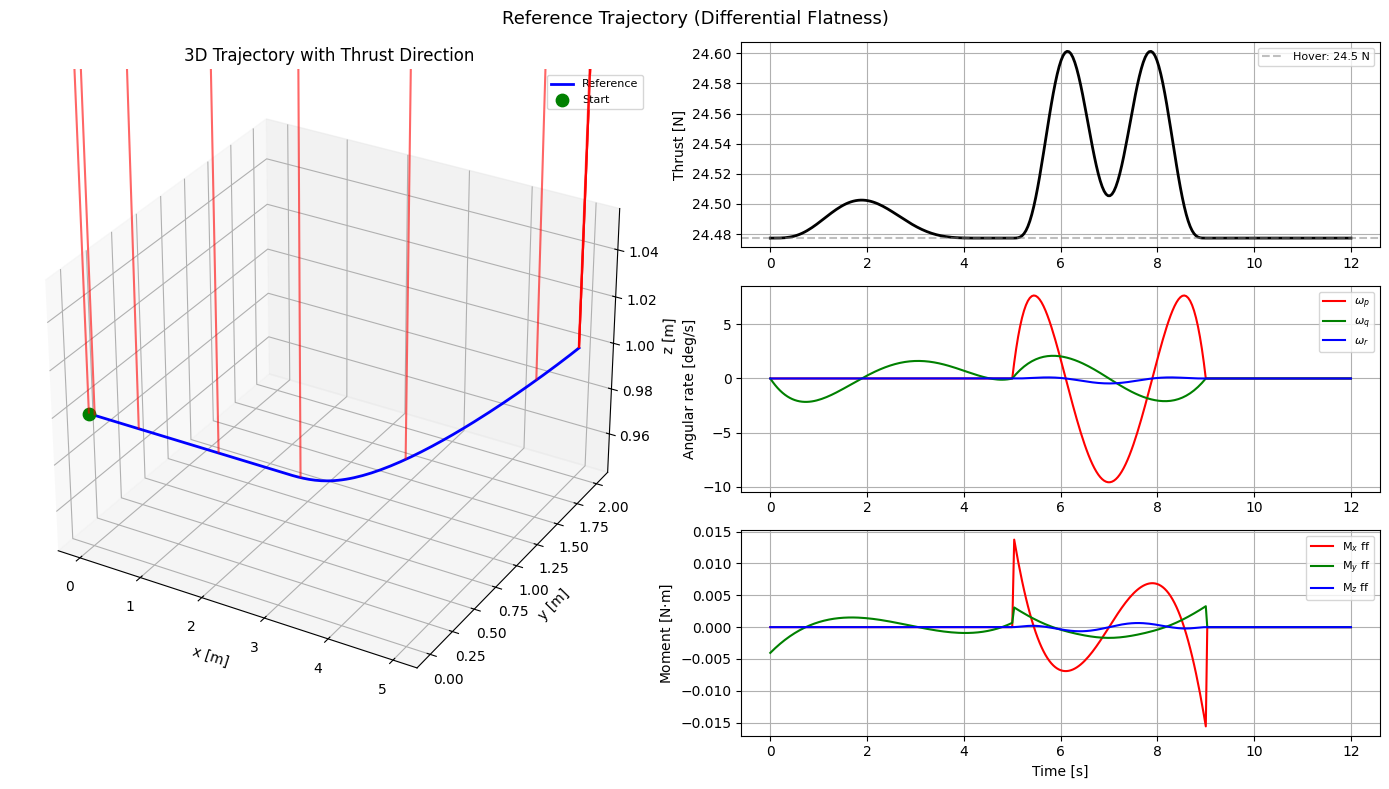

In [35]:
# 3D reference trajectory with thrust direction and angular velocity
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 8))

ax3d = fig.add_subplot(121, projection='3d')
ax3d.plot(p_ref[:, 0], p_ref[:, 1], -p_ref[:, 2], 'b-', linewidth=2, label='Reference')
ax3d.scatter(*p_ref[0, :2], -p_ref[0, 2], color='g', s=80, zorder=5, label='Start')

n_arrows = 12
arrow_idx = np.round(np.linspace(0, len(t_eval)-1, n_arrows)).astype(int)
for k in arrow_idx:
    thrust_dir = -R_ref[k, :, 2]
    scale = 0.3
    ax3d.quiver(p_ref[k, 0], p_ref[k, 1], -p_ref[k, 2],
                scale*thrust_dir[0], scale*thrust_dir[1], -scale*thrust_dir[2],
                color='r', alpha=0.6, arrow_length_ratio=0.15)

ax3d.set_xlabel('x [m]')
ax3d.set_ylabel('y [m]')
ax3d.set_zlabel('z [m]')
ax3d.set_title('3D Trajectory with Thrust Direction')
ax3d.legend(fontsize=8)

ax_T = fig.add_subplot(322)
ax_T.plot(t_eval, T_ref_val, 'k-', linewidth=2)
ax_T.axhline(mass * g, color='gray', linestyle='--', alpha=0.5, label=f'Hover: {mass*g:.1f} N')
ax_T.set_ylabel('Thrust [N]')
ax_T.legend(fontsize=8)
ax_T.grid(True)

ax_w = fig.add_subplot(324, sharex=ax_T)
for i, (label, color) in enumerate(zip(['p', 'q', 'r'], ['r', 'g', 'b'])):
    ax_w.plot(t_eval, np.rad2deg(omega_ref[:, i]), color=color, linewidth=1.5,
              label=f'$\\omega_{label}$')
ax_w.set_ylabel('Angular rate [deg/s]')
ax_w.legend(fontsize=8)
ax_w.grid(True)

ax_m = fig.add_subplot(326, sharex=ax_T)
for i, (label, color) in enumerate(zip(['x', 'y', 'z'], ['r', 'g', 'b'])):
    ax_m.plot(t_eval, flat_ref['M_ff'][:, i], color=color, linewidth=1.5,
              label=f'M$_{label}$ ff')
ax_m.set_ylabel('Moment [N$\\cdot$m]')
ax_m.set_xlabel('Time [s]')
ax_m.legend(fontsize=8)
ax_m.grid(True)

fig.suptitle('Reference Trajectory (Differential Flatness)', fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/ref_trajectory_3d.png", dpi=150)
plt.show()

## Build CasADi Integrator and Reference Inputs

In [36]:
dt = 0.01
integrator = model["build_integrator"](dt)

# Reference interpolator: pack all ref signals into one array for fast lookup
N = len(t_eval)
ref_cols = np.column_stack([
    p_ref, v_ref, a_ref,
    R_ref.reshape(N, 9), omega_ref, flat_ref["M_ff"],
])
ref_interp = interp1d(t_eval, ref_cols, axis=0, fill_value="extrapolate")

# Map ref columns -> input vector indices
ref_names = (
    ["px_ref", "py_ref", "pz_ref", "vx_ref", "vy_ref", "vz_ref",
     "ax_ref", "ay_ref", "az_ref"]
    + [f"R{i+1}{j+1}_ref" for i in range(3) for j in range(3)]
    + ["omega_x_ref", "omega_y_ref", "omega_z_ref", "Mx_ff", "My_ff", "Mz_ff"]
)
ref_idx = np.array([input_names.index(n) for n in ref_names])
d_idx = [input_names.index(n) for n in ["d_p", "d_q", "d_r"]]

def get_inputs(t, d_pqr=(0.0, 0.0, 0.0)):
    u = np.zeros(n_u)
    u[ref_idx] = ref_interp(t)
    u[d_idx] = d_pqr
    return u

def simulate(disturbance_fn=None):
    """Simulate with optional disturbance_fn(t) -> (d_p, d_q, d_r)."""
    t_sim = np.arange(t_eval[0], t_eval[-1], dt)
    x_hist = np.zeros((n_x, len(t_sim)))
    x_k, z_k = x0.copy(), np.zeros(n_z)
    for k in range(len(t_sim)):
        x_hist[:, k] = x_k
        d = disturbance_fn(t_sim[k]) if disturbance_fn else (0, 0, 0)
        p_full = np.concatenate([p0, get_inputs(t_sim[k], d)])
        result = integrator(x0=x_k, z0=z_k, p=p_full)
        x_k = np.array(result["xf"]).flatten()
        z_k = np.array(result["zf"]).flatten()
    return t_sim, x_hist

print(f"Integrator ready (dt={dt}s)")
print(f"Input ordering: {input_names}")

Integrator ready (dt=0.01s)
Input ordering: ['Mx_ff', 'My_ff', 'Mz_ff', 'R11_ref', 'R12_ref', 'R13_ref', 'R21_ref', 'R22_ref', 'R23_ref', 'R31_ref', 'R32_ref', 'R33_ref', 'ax_ref', 'ay_ref', 'az_ref', 'd_p', 'd_q', 'd_r', 'omega_x_ref', 'omega_y_ref', 'omega_z_ref', 'px_ref', 'py_ref', 'pz_ref', 'vx_ref', 'vy_ref', 'vz_ref']


## Nominal Simulation

In [37]:
# Initial condition: start at first waypoint, identity rotation
x0 = np.array(model["x0"], dtype=float)
for name, val in [("px", p_ref[0, 0]), ("py", p_ref[0, 1]), ("pz", p_ref[0, 2]),
                  ("R11", 1.0), ("R22", 1.0), ("R33", 1.0)]:
    x0[state_names.index(name)] = val

t_sim, x_hist = simulate()
print(f"Final pos: {[x_hist[state_names.index(s), -1] for s in ['px','py','pz']]}")
print(f"Reference: {p_ref[-1].tolist()}")

Final pos: [5.020532025642917, 1.821379136758362, -0.9997078135302879]
Reference: [5.0, 2.0, -1.0]


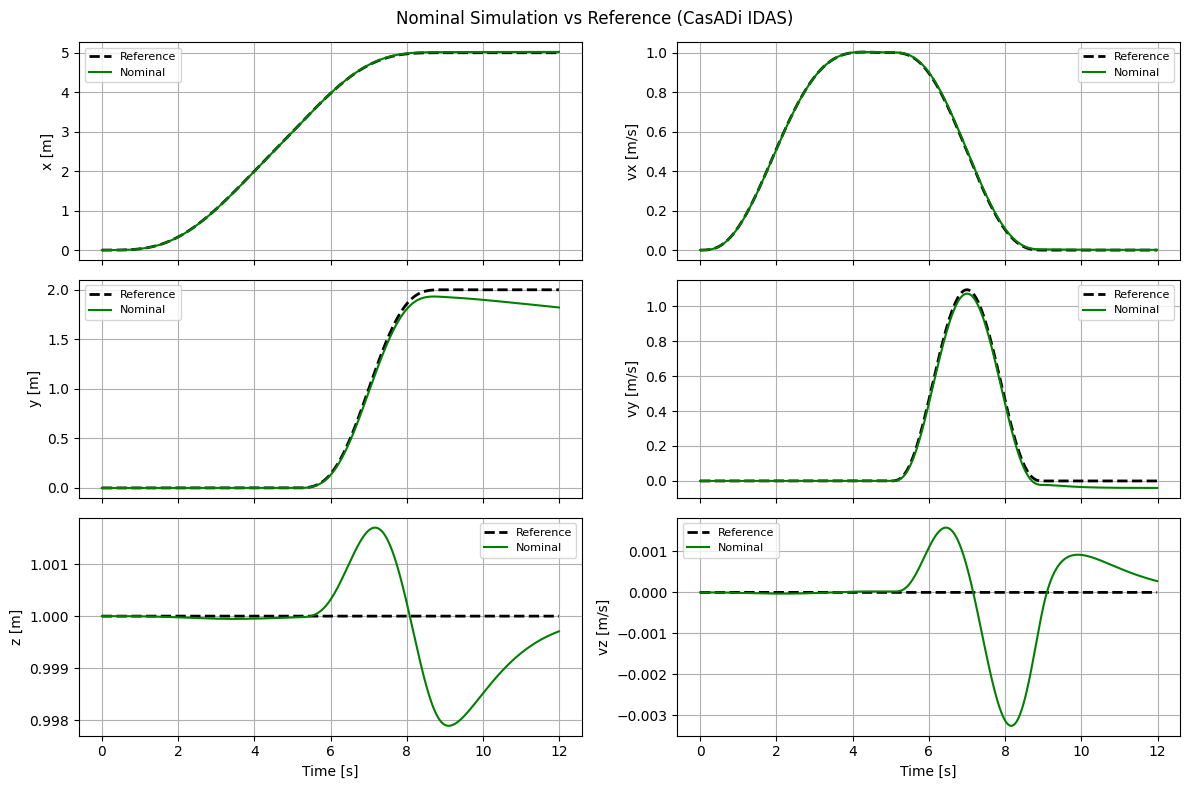

In [38]:
# Plot nominal vs reference
idx_px = state_names.index("px")
idx_py = state_names.index("py")
idx_pz = state_names.index("pz")
idx_vx = state_names.index("vx")
idx_vy = state_names.index("vy")
idx_vz = state_names.index("vz")
idx_ox = state_names.index("omega_x")
idx_oy = state_names.index("omega_y")
idx_oz = state_names.index("omega_z")

p_ref_sim = interp1d(t_eval, p_ref, axis=0, fill_value="extrapolate")(t_sim)
v_ref_sim = interp1d(t_eval, v_ref, axis=0, fill_value="extrapolate")(t_sim)
n_steps = len(t_sim)

fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True)
pos_labels = ["x [m]", "y [m]", "z [m]"]
vel_labels = ["vx [m/s]", "vy [m/s]", "vz [m/s]"]
pos_indices = [idx_px, idx_py, idx_pz]
vel_indices = [idx_vx, idx_vy, idx_vz]

for i in range(3):
    axes[i, 0].plot(t_sim, z_sign[i] * p_ref_sim[:, i], "k--", linewidth=2, label="Reference")
    axes[i, 0].plot(t_sim, z_sign[i] * x_hist[pos_indices[i]], "g-", linewidth=1.5, label="Nominal")
    axes[i, 0].set_ylabel(pos_labels[i])
    axes[i, 0].legend(fontsize=8)
    axes[i, 0].grid(True)

    axes[i, 1].plot(t_sim, z_sign[i] * v_ref_sim[:, i], "k--", linewidth=2, label="Reference")
    axes[i, 1].plot(t_sim, z_sign[i] * x_hist[vel_indices[i]], "g-", linewidth=1.5, label="Nominal")
    axes[i, 1].set_ylabel(vel_labels[i])
    axes[i, 1].legend(fontsize=8)
    axes[i, 1].grid(True)

axes[-1, 0].set_xlabel("Time [s]")
axes[-1, 1].set_xlabel("Time [s]")
fig.suptitle("Nominal Simulation vs Reference (CasADi IDAS)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/nominal_vs_ref_casadi.png", dpi=150)
plt.show()

## Disturbed Simulations

Square-wave gyro bias disturbances at varied frequencies and phases.

In [39]:
# Disturbed simulations: gyro bias square waves across frequencies, phases, and axes
D_GYRO = float(max(DIST_INPUTS.values()))

frequencies = np.arange(0.1, 1.0, 0.2)
n_phases, n_axes = 6, 4  # 0=p, 1=q, 2=r, 3=all

print(f"Disturbance: +/-{D_GYRO} rad/s gyro bias")
print(f"Frequencies: {frequencies} Hz")
print(f"Total simulations: {len(frequencies)*n_phases*n_axes}")

Disturbance: +/-0.01 rad/s gyro bias
Frequencies: [0.1 0.3 0.5 0.7 0.9] Hz
Total simulations: 120


In [40]:
disturbed_trajectories = []
for freq in frequencies:
    period = 1.0 / freq
    for phase in np.linspace(0, period, n_phases, endpoint=False):
        for ax in range(n_axes):
            def make_dist(f, ph, a):
                def dist(t):
                    d = D_GYRO if (((t + ph) % (1/f)) * f) < 0.5 else -D_GYRO
                    if a < 3:
                        v = [0, 0, 0]; v[a] = d; return tuple(v)
                    return (d, d, d)
                return dist
            try:
                _, xh = simulate(make_dist(freq, phase, ax))
                disturbed_trajectories.append(xh)
            except Exception:
                pass

print(f"Completed {len(disturbed_trajectories)}/{len(frequencies)*n_phases*n_axes} disturbed simulations")

Completed 120/120 disturbed simulations


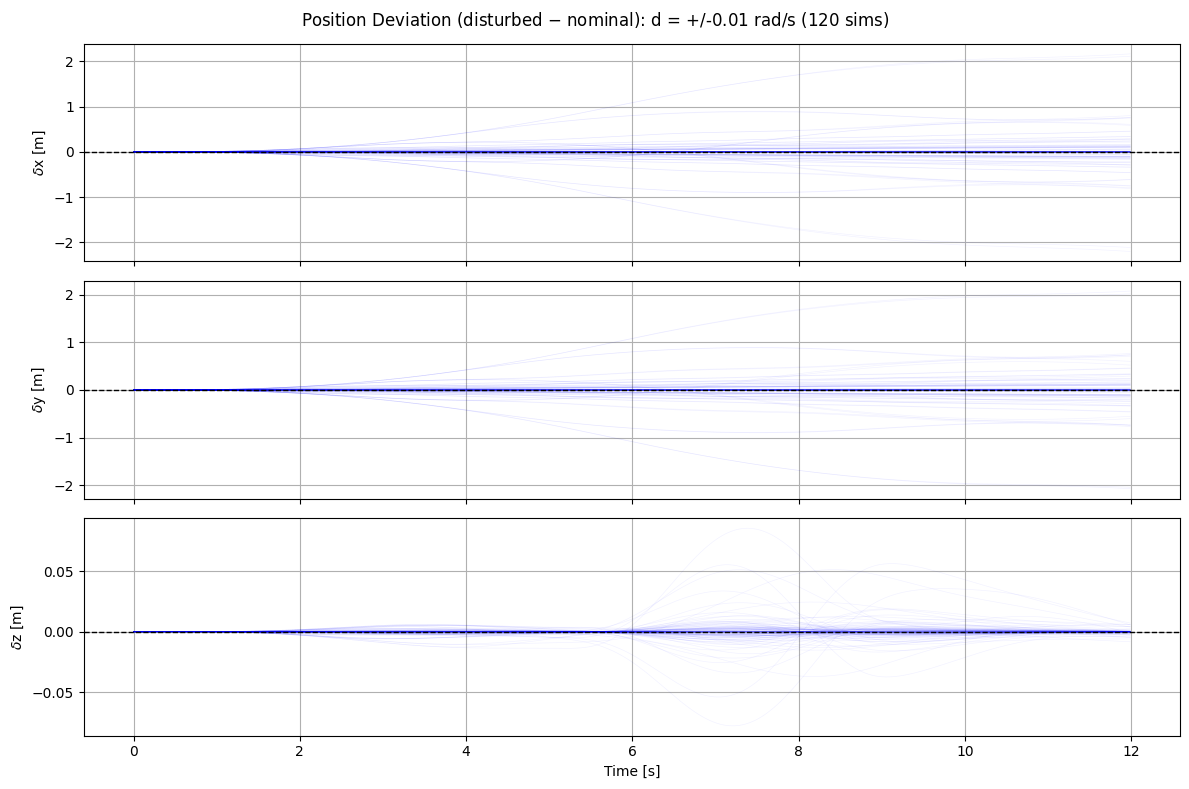

In [41]:
# Position deviation (simulation only, before LMI)
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
pos_labels = ["x [m]", "y [m]", "z [m]"]
pos_indices = [idx_px, idx_py, idx_pz]

for i, (ax, label, idx_s) in enumerate(zip(axes, pos_labels, pos_indices)):
    for traj in disturbed_trajectories:
        delta = z_sign[i] * (traj[idx_s] - x_hist[idx_s])
        ax.plot(t_sim, delta, "b-", alpha=0.05, linewidth=0.5)
    ax.axhline(0, color="k", ls="--", lw=1)
    ax.set_ylabel(f"$\\delta${label}")
    ax.grid(True)

axes[-1].set_xlabel("Time [s]")
fig.suptitle(f"Position Deviation (disturbed $-$ nominal): d = +/-{D_GYRO} rad/s ({len(disturbed_trajectories)} sims)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/position_flowpipe_casadi.png", dpi=150)
plt.show()

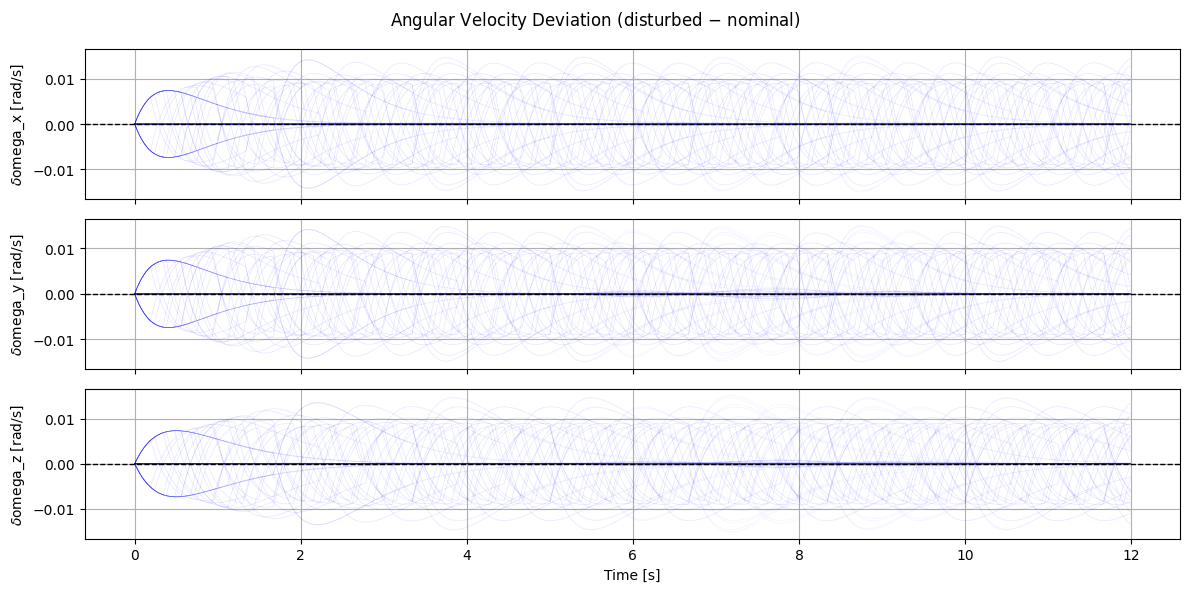

In [42]:
# Angular velocity error: disturbed - nominal
omega_ref_sim = interp1d(t_eval, omega_ref, axis=0, fill_value="extrapolate")(t_sim)

fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
omega_labels = ['omega_x [rad/s]', 'omega_y [rad/s]', 'omega_z [rad/s]']
omega_indices = [idx_ox, idx_oy, idx_oz]

for i, (ax, label, idx_s) in enumerate(zip(axes, omega_labels, omega_indices)):
    for traj in disturbed_trajectories:
        ax.plot(t_sim, traj[idx_s] - x_hist[idx_s], 'b-', alpha=0.05, linewidth=0.5)
    ax.axhline(0, color='k', ls='--', lw=1)
    ax.set_ylabel(f'$\\delta${label}')
    ax.grid(True)

axes[-1].set_xlabel('Time [s]')
fig.suptitle('Angular Velocity Deviation (disturbed $-$ nominal)')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/omega_error.png", dpi=150)
plt.show()

## Partition States

Identify which states belong to the Lie group (SE_2(3) kinematics) and which
are remaining (angular rates, integrators). This determines the cascaded LMI structure:
- Layer 1 operates on the remaining states (rotational dynamics)
- Layer 2 operates on the 9D Lie algebra error

In [43]:
partition = partition_states(state_names, lie_spec)
print(f"Lie group states ({len(partition['lie_group'])}): {partition['lie_group']}")
print(f"Remaining (not in Lie algebra): {partition['remaining']}")

# Sample trajectory at NUM_SAMPLES points for LMI
idx_sample = np.round(np.linspace(0, len(t_eval) - 1, NUM_SAMPLES)).astype(int)
times_sample = t_eval[idx_sample]
omega_refs_sample = omega_ref[idx_sample]
v_refs_sample = v_ref[idx_sample]
a_refs_sample = a_body_ref[idx_sample]

# Inertia
Ixx, Iyy, Izz = Ixx_val, Iyy_val, Izz_val

# Extract controller gains from parameters
Kw_x, Kw_y, Kw_z = float(param_dict['Kw_x']), float(param_dict['Kw_y']), float(param_dict['Kw_z'])
Kr_x, Kr_y, Kr_z = float(param_dict['Kr_x']), float(param_dict['Kr_y']), float(param_dict['Kr_z'])

Kp_se23 = np.array([float(param_dict['Kp_px']) * float(param_dict['Kp_vx']),
                     float(param_dict['Kp_py']) * float(param_dict['Kp_vy']),
                     float(param_dict['Kp_pz']) * float(param_dict['Kp_vz'])])
Kd_se23 = np.array([float(param_dict['Kp_vx']), float(param_dict['Kp_vy']), float(param_dict['Kp_vz'])])
Kpq_se23 = np.array([Kr_x, Kr_y, Kr_z])
Ki_se23 = np.array([float(param_dict['Ki_vx']), float(param_dict['Ki_vy']), float(param_dict['Ki_vz'])])

print(f"\nLayer 1: rotational dynamics ({len(partition['remaining'])} remaining states)")
print(f"  Rate gains: Kw = [{Kw_x}, {Kw_y}, {Kw_z}]")
print(f"  Attitude gains: Kr = [{Kr_x}, {Kr_y}, {Kr_z}]")
print(f"\nLayer 2: SE_2(3) kinematics (9D Lie algebra error)")
print(f"  PD gains: Kp={Kp_se23}, Kd={Kd_se23}, Kpq={Kpq_se23}")
print(f"  Ki gains (disturbance channel): Ki={Ki_se23}")

Lie group states (15): ['R11', 'R12', 'R13', 'R21', 'R22', 'R23', 'R31', 'R32', 'R33', 'px', 'py', 'pz', 'vx', 'vy', 'vz']
Remaining (not in Lie algebra): ['omega_x', 'omega_y', 'omega_z', 'vel_err_ix', 'vel_err_iy', 'vel_err_iz']

Layer 1: rotational dynamics (6 remaining states)
  Rate gains: Kw = [5.0, 5.0, 4.0]
  Attitude gains: Kr = [6.0, 6.0, 4.0]

Layer 2: SE_2(3) kinematics (9D Lie algebra error)
  PD gains: Kp=[2.   2.   3.75], Kd=[2.  2.  2.5], Kpq=[6. 6. 4.]
  Ki gains (disturbance channel): Ki=[0.1 0.1 0.1]


In [44]:
# =============================================================================
# Build SymPy Symbolic State Space from DAE IR
# =============================================================================
# Following the structured_nonlinear.ipynb pattern:
#   DaeIR -> ir_to_symbolic_statespace -> get_error_dynamics -> extract subblocks
#
# Partition logic:
#   1. Separate disturbances (inputs + states) from dynamics
#   2. Partition dynamics into Lie group (SE_2(3)) and not-Lie (omega)
#   Layer 1 = not-Lie dynamics (omega)

from cp_reach.ir import DaeIR, ir_to_symbolic_statespace
import sympy as sp

print("Building symbolic state space from DAE IR...")
ir = DaeIR.from_json_str(dae_json)
ss = ir_to_symbolic_statespace(ir, simplify=True)

print(f"States ({len(ss.get_state_names())}): {ss.get_state_names()}")
print(f"Inputs ({len(ss.get_input_names())}): {ss.get_input_names()}")

# Separate disturbances from dynamics:
#   disturbances = disturbance inputs + disturbance states (from lie spec)
#   dynamics = everything else
#   partition dynamics into: Lie group states vs remaining (Layer 1)
all_state_names = ss.get_state_names()
lie_state_set = set(partition['lie_group'])
dist_state_set = set(dist_state_names)
layer1_names = [s for s in all_state_names if s not in lie_state_set and s not in dist_state_set]

print(f"\nPartition:")
print(f"  Lie group states ({len(partition['lie_group'])}): {partition['lie_group']}")
print(f"  Layer 1 dynamics ({len(layer1_names)}): {layer1_names}")
print(f"  Disturbance states ({len(dist_state_names)}): {dist_state_names}")
print(f"  Disturbance inputs ({len(dist_input_names)}): {dist_input_names}")

# Compute error dynamics with disturbance inputs from lie spec
error_dyn = ss.get_error_dynamics(disturbance_inputs=dist_input_names)
J_full = error_dyn['J']       # 21x21 symbolic Jacobian
B_d_full = error_dyn['B_d']   # 21x3 symbolic disturbance matrix

print(f"\nFull Jacobian J shape: {J_full.shape}")
print(f"Disturbance matrix B_d shape: {B_d_full.shape}")

# Substitute parameters
param_subs_sym = {sym: param_dict[str(sym)] for sym in ss.param_symbols if str(sym) in param_dict}
J_full_params = J_full.subs(param_subs_sym)
B_d_full_params = B_d_full.subs(param_subs_sym)

# Extract Layer 1 subblock from the full Jacobian
ss_state_names = ss.get_state_names()
layer1_idx = [ss_state_names.index(s) for s in layer1_names]
print(f"\nLayer 1 state indices in full system: {layer1_idx}")

J_layer1_sym = J_full_params[layer1_idx, :][:, layer1_idx]  # symbolic
B_d_layer1 = np.array(B_d_full_params[layer1_idx, :], dtype=float)  # numeric

print(f"\nSymbolic Layer 1 Jacobian ({len(layer1_names)}x{len(layer1_names)}):")
sp.pprint(J_layer1_sym)

print(f"\nDisturbance matrix B_d (Layer 1 rows):")
print(B_d_layer1)

# Identify which Layer 1 symbols appear nonlinearly in the Jacobian
layer1_symbols = [sp.Symbol(n) for n in layer1_names]
nonlinear_syms = [s for s in layer1_symbols if any(s in elem.free_symbols for elem in J_layer1_sym)]
print(f"\nNonlinear symbols in Layer 1 Jacobian: {nonlinear_syms}")

Building symbolic state space from DAE IR...
States (21): ['px', 'py', 'pz', 'vx', 'vy', 'vz', 'R11', 'R12', 'R13', 'R21', 'R22', 'R23', 'R31', 'R32', 'R33', 'omega_x', 'omega_y', 'omega_z', 'vel_err_ix', 'vel_err_iy', 'vel_err_iz']
Inputs (27): ['px_ref', 'py_ref', 'pz_ref', 'vx_ref', 'vy_ref', 'vz_ref', 'ax_ref', 'ay_ref', 'az_ref', 'R11_ref', 'R12_ref', 'R13_ref', 'R21_ref', 'R22_ref', 'R23_ref', 'R31_ref', 'R32_ref', 'R33_ref', 'omega_x_ref', 'omega_y_ref', 'omega_z_ref', 'Mx_ff', 'My_ff', 'Mz_ff', 'd_p', 'd_q', 'd_r']

Partition:
  Lie group states (15): ['R11', 'R12', 'R13', 'R21', 'R22', 'R23', 'R31', 'R32', 'R33', 'px', 'py', 'pz', 'vx', 'vy', 'vz']
  Layer 1 dynamics (3): ['omega_x', 'omega_y', 'omega_z']
  Disturbance states (3): ['vel_err_ix', 'vel_err_iy', 'vel_err_iz']
  Disturbance inputs (3): ['d_p', 'd_q', 'd_r']

Full Jacobian J shape: (21, 21)
Disturbance matrix B_d shape: (21, 3)

Layer 1 state indices in full system: [15, 16, 17]

Symbolic Layer 1 Jacobian (3x3):
⎡-

## Layer 1: Rotational Dynamics LMI (from Symbolic Jacobian)

The Layer 1 Jacobian is **automatically extracted** from the Modelica model's SymPy
state space, following the same pattern as `structured_nonlinear.ipynb`:

1. `ir_to_symbolic_statespace(ir)` → eliminates algebraic variables → pure ODE
2. `ss.get_error_dynamics(['d_p', 'd_q', 'd_r'])` → symbolic Jacobian J (21×21) and B_d (21×3)
3. Extract omega-to-omega subblock J_omega (3×3)
4. If J_omega has state-dependent entries: `polytopic_jacobians()` evaluates at 2^n corners
5. If J_omega is constant (e.g., gyroscopic compensation cancels coupling): single vertex

This generalizes: no hardcoded Euler equation structure needed.

In [45]:
from cp_reach.reachability import (
    solve_disturbance_LMI,
    polytopic_jacobians,
    solve_time_varying_polytopic_lmi,
    compute_state_bounds,
    se23_drift_matrix,
)

# Worst-case Layer 1 state values across the entire trajectory
# For omega states, this is max(|omega_ref|) per axis
layer1_wc = {}
for name in layer1_names:
    omega_state_names = group['body_angular_velocity']
    if name in omega_state_names:
        omega_axis = omega_state_names.index(name)
        layer1_wc[name] = np.max(np.abs(omega_ref[:, omega_axis]))

print(f"Worst-case Layer 1 state values:")
for name, val in layer1_wc.items():
    print(f"  {name}: {val:.4f}")

# Build A matrix vertices from the symbolic Jacobian
if nonlinear_syms:
    # State-dependent Jacobian -> polytopic evaluation at 2^n corners
    ref_vals = {sp.Symbol(s): np.array([0.0]) for s in layer1_wc}
    err_bounds = {sp.Symbol(s): float(v) for s, v in layer1_wc.items()}
    ref_vals_nl = {s: ref_vals[s] for s in nonlinear_syms if s in ref_vals}
    err_bounds_nl = {s: err_bounds[s] for s in nonlinear_syms if s in err_bounds}

    polytopes = polytopic_jacobians(J_layer1_sym, ref_vals_nl, err_bounds_nl, nonlinear_syms)
    A_list_layer1 = polytopes[0]  # Single time point -> one list of vertices
    print(f"\nPolytopic vertices: {len(A_list_layer1)} (2^{len(nonlinear_syms)} corners)")
else:
    # Constant Jacobian -> single vertex (no state-dependent terms)
    A_const = np.array(J_layer1_sym, dtype=float)
    A_list_layer1 = [A_const]
    print(f"\nConstant Jacobian (gyroscopic compensation cancels coupling) -> 1 vertex")

for i, A in enumerate(A_list_layer1):
    eigvals = np.linalg.eigvals(A)
    print(f"  Vertex {i}: max Re(eig) = {np.max(np.real(eigvals)):.4f}")

# Solve time-invariant polytopic LMI
layer1_result = solve_disturbance_LMI(A_list_layer1, B_d_layer1, w_max=D_GYRO)

# Per-axis error bounds from invariant ellipsoid
P_l1_inv = np.linalg.inv(layer1_result['P'])
c_l1 = layer1_result['cost']
layer1_bounds = np.sqrt(c_l1 * np.diag(P_l1_inv))

# Extract omega bounds specifically (for passing to Layer 2)
omega_bounds = np.array([layer1_bounds[layer1_names.index(n)] for n in group['body_angular_velocity']])

print(f"\nLayer 1 results (alpha = {layer1_result['alpha']:.4f}):")
for name, bound in zip(layer1_names, layer1_bounds):
    print(f"  {name}: +/-{bound:.6f}")
print(f"\nOmega bounds for Layer 2: {omega_bounds}")

Worst-case Layer 1 state values:
  omega_x: 0.1670
  omega_y: 0.0376
  omega_z: 0.0080

Constant Jacobian (gyroscopic compensation cancels coupling) -> 1 vertex
  Vertex 0: max Re(eig) = -4.0000

Layer 1 results (alpha = 1.0000):
  omega_x: +/-0.028002
  omega_y: +/-0.028002
  omega_z: +/-0.028002

Omega bounds for Layer 2: [0.02800231 0.02800231 0.02800229]


## Layer 2: SE_2(3) Kinematics (9x9 Log-Linear LMI)

The kinematic subsystem is exact log-linear on SE_2(3). The error dynamics are:

$$\dot{\xi} = A(t)\,\xi + B_{\omega}\,\tilde{\omega} + B_{z}\,\tilde{z}$$

where:
- $\xi = [\xi_p, \xi_v, \xi_R] \in \mathbb{R}^9$ is the Lie algebra error
- $A(t) = -\mathrm{ad}_{\bar{n}} + A_C - B_0 K_{\mathrm{PD}}$ (9x9, PD feedback only)
- $\tilde{\omega}$: omega error from Layer 1 $\to$ rotation block
- $\tilde{z}$: integrator error (bounded input) $\to$ velocity block via $K_i$ gains

Two disturbance channels with separate bounds: $\|\tilde{\omega}\| \leq d_\omega$,
$\|\tilde{z}\| \leq d_z$.

Three options from least to most expensive:
- **Option A**: Single worst-case A matrix (1 vertex, most conservative)
- **Option B**: Sampled A(t) as polytopic vertices (N vertices, time-invariant P)
- **Option C**: Time-varying polynomial Lyapunov M(t) (tightest, adapts along trajectory)

In [46]:
# Build PD controller matrices for 9x9 SE_2(3) system
B0 = np.zeros((9, 6))
B0[3:6, 0:3] = np.eye(3)  # acceleration -> velocity block
B0[6:9, 3:6] = np.eye(3)  # angular rate -> rotation block

K_pd = np.zeros((6, 9))
K_pd[0:3, 0:3] = np.diag(Kp_se23)   # xi_p -> accel command
K_pd[0:3, 3:6] = np.diag(Kd_se23)   # xi_v -> accel command
K_pd[3:6, 6:9] = np.diag(Kpq_se23)  # xi_R -> rate command

BK_pd = B0 @ K_pd

# Two disturbance channels:
#   Channel 1: omega error from Layer 1 -> rotation block (rows 6-8)
#   Channel 2: integrator error z_tilde -> velocity block (rows 3-5) via Ki gains
B_omega = np.zeros((9, 3))
B_omega[6:9, :] = np.eye(3)

B_int = np.zeros((9, 3))
B_int[3:6, :] = np.diag(Ki_se23)  # Ki * z_tilde enters velocity dynamics

# Per-channel scalar disturbance bounds
w_omega = float(np.max(omega_bounds))    # worst-case omega error from Layer 1
w_int = float(np.max(dist_state_bounds)) # worst-case integrator error

print(f"Channel 1 (omega): B_omega {B_omega.shape}, w_max = {w_omega:.4f} rad/s")
print(f"Channel 2 (integrator): B_int {B_int.shape}, w_max = {w_int:.4f}")
print(f"  Ki gains: {Ki_se23}")

Channel 1 (omega): B_omega (9, 3), w_max = 0.0280 rad/s
Channel 2 (integrator): B_int (9, 3), w_max = 0.0500
  Ki gains: [0.1 0.1 0.1]


In [47]:
from cp_reach.reachability import sample_ellipsoid_boundary, se23_expmap

# --- Two-channel LMI for SE_2(3) ---
# xdot = A_i x + B_omega w1 + B_int w2
# Certify V(x) = x^T P x <= mu1*w1^2 + mu2*w2^2

def solve_2channel_lmi(alpha, A_list, B1, B2, w1_max, w2_max):
    """Solve 2-channel disturbance LMI at fixed alpha."""
    import cvxpy as cvx
    n = A_list[0].shape[0]
    m1, m2 = B1.shape[1], B2.shape[1]
    I_n, I_m1, I_m2 = np.eye(n), np.eye(m1), np.eye(m2)
    Z12, Z21 = np.zeros((m1, m2)), np.zeros((m2, m1))

    P = cvx.Variable((n, n), symmetric=True)
    mu1 = cvx.Variable(nonneg=True)
    mu2 = cvx.Variable(nonneg=True)
    gamma = mu1 * w1_max**2 + mu2 * w2_max**2

    constraints = [P >> I_n]
    for Ai in A_list:
        TL = Ai.T @ P + P @ Ai + alpha * P
        LMI = cvx.bmat([
            [TL,          P @ B1,              P @ B2],
            [B1.T @ P,   -alpha * mu1 * I_m1,  Z12],
            [B2.T @ P,    Z21,                -alpha * mu2 * I_m2],
        ])
        constraints.append(LMI << 0)

    prob = cvx.Problem(cvx.Minimize(gamma), constraints)
    for solver in [cvx.CVXOPT, cvx.MOSEK, cvx.SCS]:
        try:
            prob.solve(solver=solver)
            if prob.status in ["optimal", "optimal_inaccurate"]:
                break
        except Exception:
            continue

    return {
        'P': P.value, 'mu1': float(mu1.value), 'mu2': float(mu2.value),
        'cost': float(gamma.value), 'alpha': alpha, 'status': prob.status,
    }

# --- Option A: Single worst-case A matrix ---
v_wc = np.max(np.abs(v_ref), axis=0)
a_wc = np.max(np.abs(a_body_ref), axis=0)
omega_wc_kin = np.max(np.abs(omega_ref), axis=0)

A_drift_wc = se23_drift_matrix(v_wc, a_wc, omega_wc_kin)
A_cl_wc = A_drift_wc - BK_pd
A_list_kin = [A_cl_wc]

# Eigenvalue-based alpha upper bound
eigs_cl = np.linalg.eigvals(A_cl_wc)
alpha_upper = max(-np.max(np.real(eigs_cl)), 0.1)
print(f"Closed-loop eigenvalues (max Re): {np.max(np.real(eigs_cl)):.4f}")
print(f"Alpha search range: [1e-5, {alpha_upper:.4f}]")

# Line search over alpha
import scipy.optimize
alpha_opt = scipy.optimize.fminbound(
    lambda a: solve_2channel_lmi(a, A_list_kin, B_omega, B_int, w_omega, w_int)['cost'],
    x1=1e-5, x2=alpha_upper,
)

layer2_result = solve_2channel_lmi(alpha_opt, A_list_kin, B_omega, B_int, w_omega, w_int)
P_kin = layer2_result['P']
cost_kin = layer2_result['cost']

print(f"\nLayer 2 LMI (2-channel, alpha={alpha_opt:.4f}, status={layer2_result['status']}):")
print(f"  mu_omega = {layer2_result['mu1']:.6f}, mu_int = {layer2_result['mu2']:.6f}")
print(f"  cost (invariant level) = {cost_kin:.6f}")

# --- Lie algebra bounds (axis-aligned from ellipsoid) ---
P_inv = np.linalg.inv(P_kin)
xi_bounds_alg = np.sqrt(cost_kin * np.diag(P_inv))

xi_names = ['xi_px', 'xi_py', 'xi_pz',
            'xi_vx', 'xi_vy', 'xi_vz',
            'xi_Rx', 'xi_Ry', 'xi_Rz']

print(f"\nLie algebra bounds (xi):")
for name, bound in zip(xi_names, xi_bounds_alg):
    print(f"  {name}: +/-{bound:.6f}")

# --- Map through exponential map: algebra -> group ---
# Scale P so the level set is {xi^T M xi <= 1}
M_scaled = P_kin / cost_kin
xi_boundary = sample_ellipsoid_boundary(M_scaled, n=500)
eta_boundary = se23_expmap(xi_boundary)

# Axis-aligned bounds in the Lie group
eta_min = np.min(eta_boundary, axis=1)
eta_max = np.max(eta_boundary, axis=1)

eta_names = ['dp_x', 'dp_y', 'dp_z',
             'dv_x', 'dv_y', 'dv_z',
             'roll', 'pitch', 'yaw']

print(f"\nLie group bounds (exp map):")
for name, lo, hi in zip(eta_names, eta_min, eta_max):
    print(f"  {name}: [{lo:+.6f}, {hi:+.6f}]")

# Use group-level bounds for plotting
pos_bounds_group = np.maximum(np.abs(eta_min[0:3]), np.abs(eta_max[0:3]))
vel_bounds_group = np.maximum(np.abs(eta_min[3:6]), np.abs(eta_max[3:6]))
rot_bounds_group = np.maximum(np.abs(eta_min[6:9]), np.abs(eta_max[6:9]))

Closed-loop eigenvalues (max Re): -1.0005
Alpha search range: [1e-5, 1.0005]


/home/micah/miniconda3/envs/lie/lib/python3.13/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(



Layer 2 LMI (2-channel, alpha=0.6545, status=optimal):
  mu_omega = 2.339429, mu_int = 0.068848
  cost (invariant level) = 0.002007

Lie algebra bounds (xi):
  xi_px: +/-0.036200
  xi_py: +/-0.035645
  xi_pz: +/-0.012400
  xi_vx: +/-0.040718
  xi_vy: +/-0.040004
  xi_vz: +/-0.020583
  xi_Rx: +/-0.010815
  xi_Ry: +/-0.010816
  xi_Rz: +/-0.028619

Lie group bounds (exp map):
  dp_x: [-0.034674, +0.034674]
  dp_y: [-0.032033, +0.032033]
  dp_z: [-0.011752, +0.011752]
  dv_x: [-0.039952, +0.039955]
  dv_y: [-0.038884, +0.038886]
  dv_z: [-0.020246, +0.020246]
  roll: [-0.010779, +0.010779]
  pitch: [-0.010815, +0.010815]
  yaw: [-0.027902, +0.027903]


In [48]:
# # --- Option B: Sampled A(t) as polytopic vertices (moderate) ---
# A_list_kin = []
# for k in range(len(times_sample)):
#     A_drift_k = se23_drift_matrix(v_refs_sample[k], a_refs_sample[k], omega_refs_sample[k])
#     A_list_kin.append(A_drift_k - BK_pd)

# layer2_ti_result = solve_disturbance_LMI(A_list_kin, B_dist, w_max=w_max_vec)

# P_xi_inv = np.linalg.inv(layer2_ti_result['P'])
# c_xi = layer2_ti_result['cost']
# xi_bounds_ti = np.sqrt(c_xi * np.diag(P_xi_inv))

# print(f"Layer 2 Option B (sampled, {len(A_list_kin)} vertices): alpha={layer2_ti_result['alpha']:.4f}")
# for name, bound in zip(xi_names, xi_bounds_ti):
#     print(f"  {name}: +/-{bound:.6f}")

In [49]:
# # --- Option C: Time-varying polynomial Lyapunov M(t) (tightest, slowest) ---
# # Build A(t) as single-vertex-per-time for the time-varying solver
# A_kinematic_tv = []
# for k in range(len(times_sample)):
#     A_drift_k = se23_drift_matrix(v_refs_sample[k], a_refs_sample[k], omega_refs_sample[k])
#     A_kinematic_tv.append([A_drift_k - BK_pd])  # single vertex per time

# # Combined scalar disturbance bound for the time-varying solver
# d_combined = np.linalg.norm(w_max_vec)

# print(f"Solving time-varying polytopic LMI (Option C)...")
# print(f"  {len(A_kinematic_tv)} time points, 1 vertex each, poly degree={NUM_SAMPLES}")
# print(f"  Combined disturbance bound: {d_combined:.6f}")

# layer2_tv_result = solve_time_varying_polytopic_lmi(
#     A_kinematic_tv, B_dist, times_sample.tolist(),
#     polynomial_degree=NUM_SAMPLES,
#     verbose=True,
# )

# if layer2_tv_result['status'] in ['infeasible', None]:
#     print("Time-varying LMI failed — falling back to Option A")
#     xi_bounds = xi_bounds_wc
#     active_option = 'A'
# else:
#     xi_bounds_tv_result = compute_state_bounds(
#         layer2_tv_result['M_coefs'],
#         layer2_tv_result['mu_physical'],
#         d_combined,
#         times_sample.tolist(),
#     )
#     xi_bounds_tv = xi_bounds_tv_result['bounds_max']

#     print(f"\nLayer 2 Option C (time-varying): alpha={layer2_tv_result['alpha']:.4f}")
#     for name, bound in zip(xi_names, xi_bounds_tv):
#         print(f"  {name}: +/-{bound:.6f}")
    
#     xi_bounds = xi_bounds_tv
#     active_option = 'C'

In [50]:
# Select active bounds for plotting (group-level from exp map)
active_option = 'A'
pos_bounds = pos_bounds_group
vel_bounds = vel_bounds_group
rot_bounds = rot_bounds_group

print(f"Active option: {active_option}")
print(f"Position bounds (group): {pos_bounds} m")
print(f"Velocity bounds (group): {vel_bounds} m/s")
print(f"Rotation bounds (group): {np.rad2deg(rot_bounds)} deg")

Active option: A
Position bounds (group): [0.03467447 0.03203301 0.01175208] m
Velocity bounds (group): [0.03995483 0.03888572 0.02024594] m/s
Rotation bounds (group): [0.61757378 0.61967481 1.59871052] deg


## Position Flowpipe with LMI Bounds

Show disturbed trajectories with the reachable set bounds from the cascaded LMI.
The xi_p bounds from Layer 2 give the position error in the Lie algebra,
which for small errors approximates the world-frame position error.

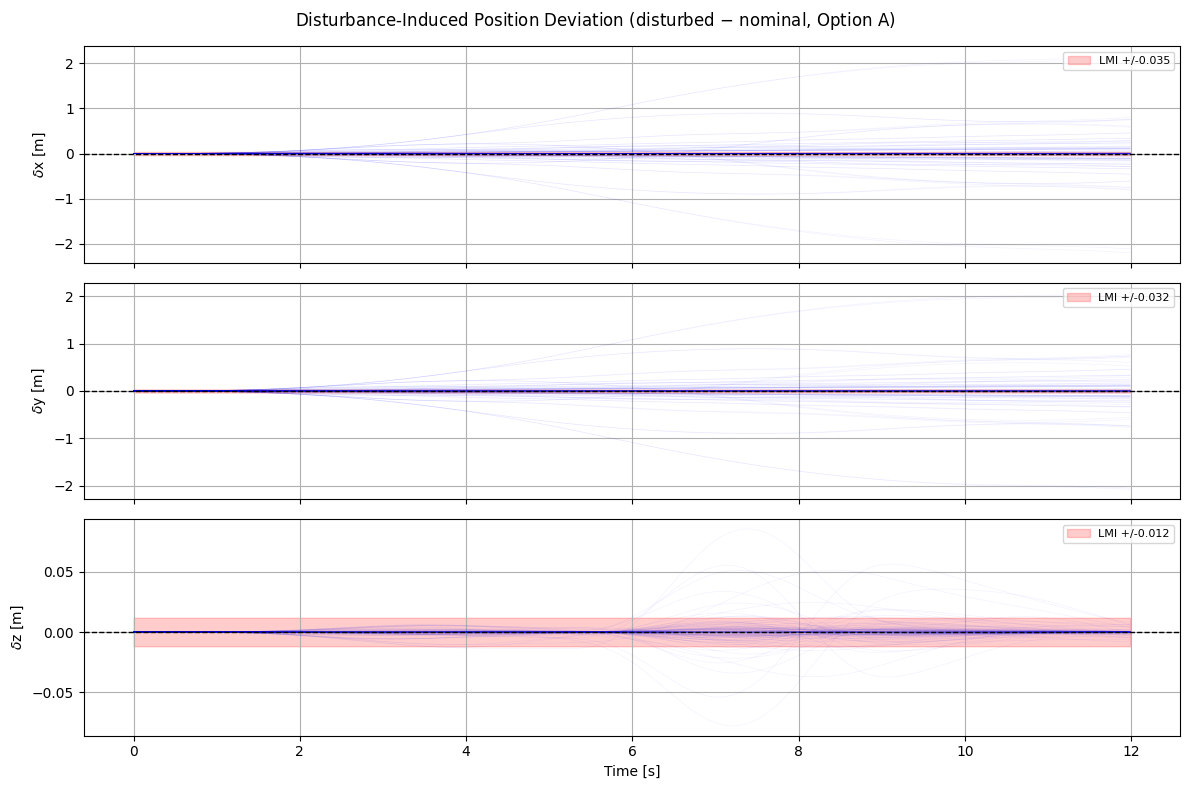

In [51]:
# Position flowpipe: disturbance-induced deviation (disturbed - nominal) with LMI bounds
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
pos_labels = ["x [m]", "y [m]", "z [m]"]
pos_indices = [idx_px, idx_py, idx_pz]

for i, (ax, label, idx_s) in enumerate(zip(axes, pos_labels, pos_indices)):
    # Disturbed - nominal deviation
    for traj in disturbed_trajectories:
        delta = z_sign[i] * (traj[idx_s] - x_hist[idx_s])
        ax.plot(t_sim, delta, "b-", alpha=0.05, linewidth=0.5)

    ax.axhline(0, color="k", ls="--", lw=1)

    # Flowpipe bounds (centered on zero since we're showing deviation)
    ax.fill_between(t_sim, -pos_bounds[i], pos_bounds[i],
                    color="r", alpha=0.2, label=f"LMI +/-{pos_bounds[i]:.3f}")

    ax.set_ylabel(f"$\\delta${label}")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True)

axes[-1].set_xlabel("Time [s]")
fig.suptitle(f"Disturbance-Induced Position Deviation (disturbed $-$ nominal, Option {active_option})")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/position_flowpipe.png", dpi=150)
plt.show()

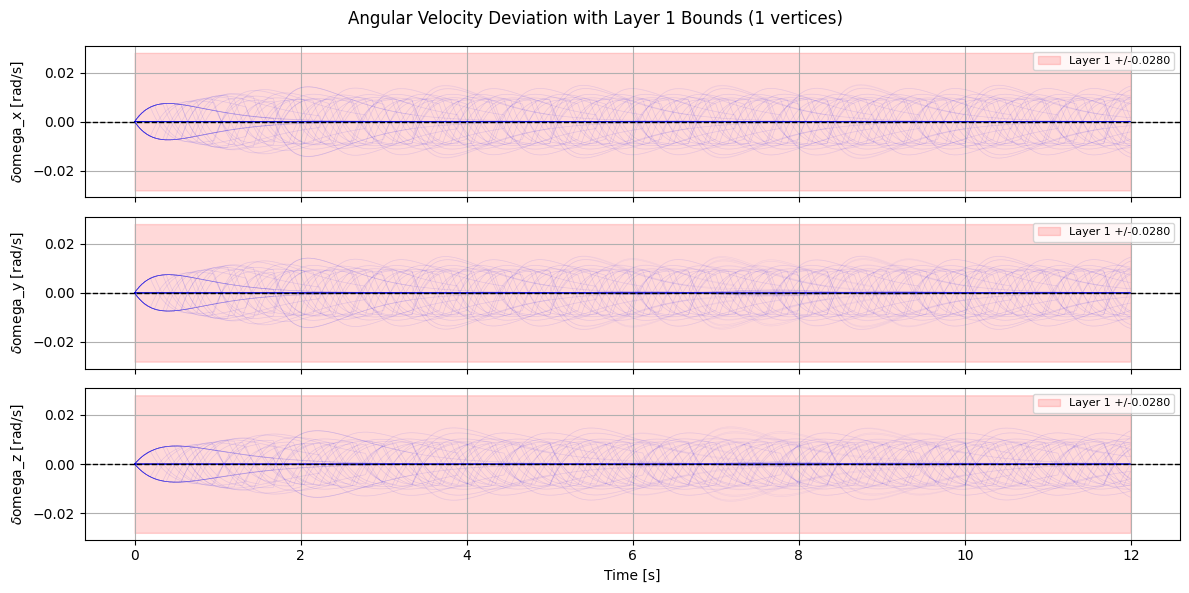

In [52]:
# Angular velocity deviation with Layer 1 bounds
fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
omega_labels = ["omega_x [rad/s]", "omega_y [rad/s]", "omega_z [rad/s]"]
omega_indices = [idx_ox, idx_oy, idx_oz]

for i, (ax, label, idx_s) in enumerate(zip(axes, omega_labels, omega_indices)):
    for traj in disturbed_trajectories:
        ax.plot(t_sim, traj[idx_s] - x_hist[idx_s], "b-", alpha=0.05, linewidth=0.5)
    ax.axhline(0, color="k", ls="--", lw=1)
    ax.fill_between(t_sim, -omega_bounds[i], omega_bounds[i],
                    color="r", alpha=0.15, label=f"Layer 1 +/-{omega_bounds[i]:.4f}")
    ax.set_ylabel(f"$\\delta${label}")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True)

axes[-1].set_xlabel("Time [s]")
fig.suptitle(f"Angular Velocity Deviation with Layer 1 Bounds ({len(A_list_layer1)} vertices)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/omega_error_lmi.png", dpi=150)
plt.show()

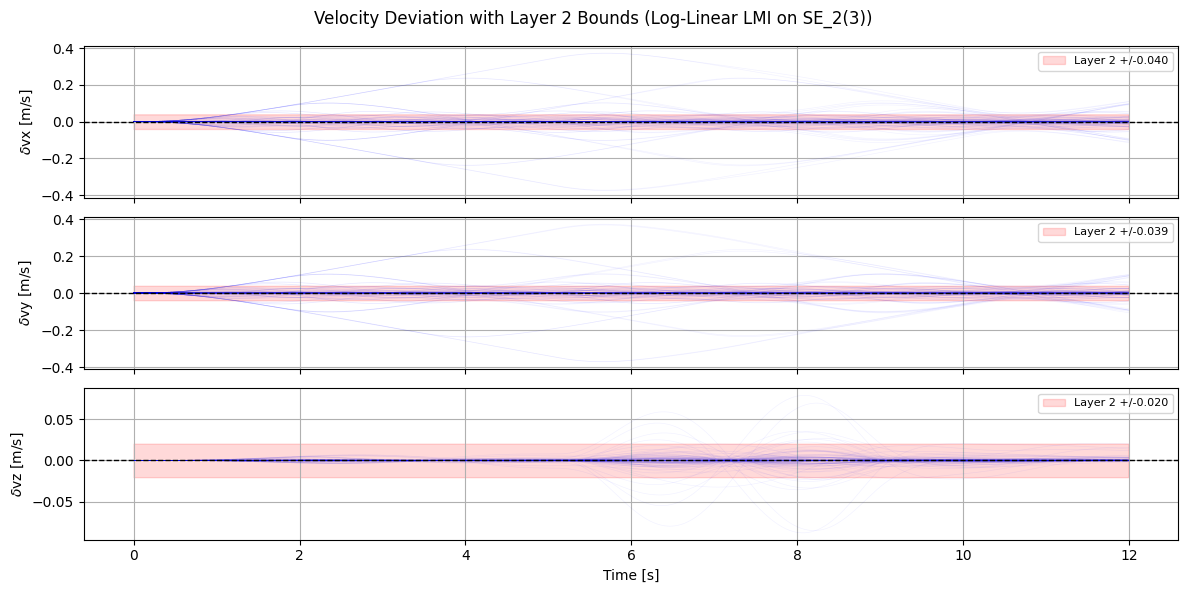

In [53]:
# Velocity deviation with Layer 2 bounds
fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
vel_labels = ["vx [m/s]", "vy [m/s]", "vz [m/s]"]
vel_indices = [state_names.index("vx"), state_names.index("vy"), state_names.index("vz")]

for i, (ax, label, idx_s) in enumerate(zip(axes, vel_labels, vel_indices)):
    for traj in disturbed_trajectories:
        ax.plot(t_sim, traj[idx_s] - x_hist[idx_s], "b-", alpha=0.05, linewidth=0.5)
    ax.axhline(0, color="k", ls="--", lw=1)
    ax.fill_between(t_sim, -vel_bounds[i], vel_bounds[i],
                    color="r", alpha=0.15, label=f"Layer 2 +/-{vel_bounds[i]:.3f}")
    ax.set_ylabel(f"$\\delta${label}")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True)

axes[-1].set_xlabel("Time [s]")
fig.suptitle("Velocity Deviation with Layer 2 Bounds (Log-Linear LMI on SE_2(3))")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/velocity_error_lmi.png", dpi=150)
plt.show()

## Summary

In [54]:
# Validation: check if all disturbance-induced deviations stay within bounds
max_deviations = {
    "position": np.zeros(3),
    "velocity": np.zeros(3),
    "omega": np.zeros(3),
}

for traj in disturbed_trajectories:
    for i, idx_s in enumerate([idx_px, idx_py, idx_pz]):
        e = np.max(np.abs(traj[idx_s] - x_hist[idx_s]))
        max_deviations["position"][i] = max(max_deviations["position"][i], e)

    for i, idx_s in enumerate(vel_indices):
        e = np.max(np.abs(traj[idx_s] - x_hist[idx_s]))
        max_deviations["velocity"][i] = max(max_deviations["velocity"][i], e)

    for i, idx_s in enumerate(omega_indices):
        e = np.max(np.abs(traj[idx_s] - x_hist[idx_s]))
        max_deviations["omega"][i] = max(max_deviations["omega"][i], e)

# Also report nominal tracking error
nom_pos_err = np.array([np.max(np.abs(x_hist[idx] - p_ref_sim[:, i])) for i, idx in enumerate(pos_indices)])

print("=" * 70)
print("CASCADED REACHABILITY SUMMARY")
print("=" * 70)
print(f"\nModel: {MODEL_NAME} (compiled from {MODELICA_FILE})")
print(f"Lie group: {group['type']}")
print(f"Trajectory: {T_total:.1f}s, {len(t_eval)} ref points, {n_steps} sim steps")
print(f"Disturbance inputs: {dist_input_names} (bounds: {dist_input_bounds})")
print(f"Disturbance states: {dist_state_names} (bounds: {dist_state_bounds})")
print(f"Simulations: {len(disturbed_trajectories)}")

print(f"\nNominal tracking error (should be small for LMI validity):")
for i, s in enumerate(["x", "y", "z"]):
    print(f"  max |nom_e_{s}| = {nom_pos_err[i]:.6f} m")

print(f"\nLayer 1 -- Dynamics (from symbolic Jacobian, {len(A_list_layer1)} vertices):")
print(f"  States: {layer1_names}")
print(f"  alpha = {layer1_result['alpha']:.4f}")
print(f"  {'State':<16} {'Max deviation':>12} {'LMI bound':>12} {'Margin':>10}")
for i, name in enumerate(layer1_names):
    if name in group['body_angular_velocity']:
        omega_axis = group['body_angular_velocity'].index(name)
        margin = layer1_bounds[i] - max_deviations["omega"][omega_axis]
        print(f"  {name:<16} {max_deviations['omega'][omega_axis]:>12.6f} {layer1_bounds[i]:>12.6f} {margin:>10.6f} {'OK' if margin >= 0 else 'EXCEEDED'}")

print(f"\nLayer 2 -- SE_2(3) kinematics (multi-channel LMI, Option {active_option}):")
print(f"  alpha = {layer2_result['alpha']:.4f}")
print(f"  Disturbance bounds: w_omega={w_omega:.4f}, w_int={w_int:.4f}")
print(f"\n  {'Variable':<16} {'Max deviation':>12} {'Group bound':>12} {'Margin':>10}")
for i, name in enumerate(["dp_x", "dp_y", "dp_z"]):
    margin = pos_bounds[i] - max_deviations["position"][i]
    status = "OK" if margin >= 0 else "EXCEEDED"
    print(f"  {name:<16} {max_deviations['position'][i]:>12.6f} {pos_bounds[i]:>12.6f} {margin:>10.6f} {status}")
for i, name in enumerate(["dv_x", "dv_y", "dv_z"]):
    margin = vel_bounds[i] - max_deviations["velocity"][i]
    status = "OK" if margin >= 0 else "EXCEEDED"
    print(f"  {name:<16} {max_deviations['velocity'][i]:>12.6f} {vel_bounds[i]:>12.6f} {margin:>10.6f} {status}")

print(f"\nComplexity comparison:")
print(f"  Cascaded:   Layer 1 = {len(A_list_layer1)} vertices ({len(layer1_names)}x{len(layer1_names)}), Layer 2 = {len(A_list_kin)} vertex (9x9)")
print(f"  Monolithic: would require polytopic vertices over full {n_x}-state system")

CASCADED REACHABILITY SUMMARY

Model: QuadrotorClosedLoop2 (compiled from models/quadrotor_closed_loop2.mo)
Lie group: SE23
Trajectory: 12.0s, 298 ref points, 1200 sim steps
Disturbance inputs: ['d_p', 'd_q', 'd_r'] (bounds: [0.01 0.01 0.01])
Disturbance states: ['vel_err_ix', 'vel_err_iy', 'vel_err_iz'] (bounds: [0.05 0.05 0.05])
Simulations: 120

Nominal tracking error (should be small for LMI validity):
  max |nom_e_x| = 0.020532 m
  max |nom_e_y| = 0.178621 m
  max |nom_e_z| = 0.002107 m

Layer 1 -- Dynamics (from symbolic Jacobian, 1 vertices):
  States: ['omega_x', 'omega_y', 'omega_z']
  alpha = 1.0000
  State            Max deviation    LMI bound     Margin
  omega_x              0.015072     0.028002   0.012931 OK
  omega_y              0.014978     0.028002   0.013024 OK
  omega_z              0.015174     0.028002   0.012828 OK

Layer 2 -- SE_2(3) kinematics (multi-channel LMI, Option A):
  alpha = 0.6545
  Disturbance bounds: w_omega=0.0280, w_int=0.0500

  Variable        